In [2]:
# Name: Temur Rustamov
# Student number: C00280204
# Project: K-clustering means with US College Data Set

In [3]:
# section 1: importing dependencies
import pandas as pd
import matplotlib.pyplot as plt # Data visualisation, Matplotlib provides full control over axes, colours,
# titles, and subplot layouts needed for professional-quality figures.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # K-Means clustering algorithm, implementation is optimised,
# well-tested, and provides useful attributes that we need for Elbow method

In [4]:
# section 2: data loading
df = pd.read_csv("./data/College_Data")
# extracting dataset
# so the data set consists of:
# Private: A factor with levels No and Yes indicating private or public university
# Apps: Number of applications received
# Accept: Number of applications accepted
# Enroll: Number of new students enrolled
# Top10perc: Pct. new students from top 10% of H.S. class
# Top25perc: Pct. new students from top 25% of H.S. class
# F.Undergrad: Number of fulltime undergraduates
# P.Undergrad: Number of parttime undergraduates
# Outstate: Out-of-state tuition
# Room.Board: Room and board costs
# Books: Estimated book costs
# Personal: Estimated personal spending
# PhD: Pct. of faculty with Ph.D.’s
# Terminal: Pct. of faculty with terminal degree
# S.F.Ratio: Student/faculty ratio
# perc.alumni Pct. alumni who donate
# Expend Instructional expenditure per student
# Grad.Rate Graduation rate

In [5]:
# section 2.1: Understand the Dataset Structure
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [6]:
df.dropna(inplace=True) #dropping columns containing NaN

In [7]:
# section 2.2: handling missing values
# K-means can not compute Euclidean distances with missing values
missing_before = df.isnull().sum().sum()
df.dropna(inplace=True)
missing_after = df.isnull().sum().sum()
print(f"Missing values: {missing_before} before → {missing_after} after dropping")
print(f"Rows remaining: {len(df)}")
print()

# Verify no missing values remain
print("Descriptive Statistics (AFTER cleaning):")
print(df.describe())
print()

Missing values: 0 before → 0 after dropping
Rows remaining: 777

Descriptive Statistics (AFTER cleaning):
               Apps        Accept       Enroll   Top10perc   Top25perc  \
count    777.000000    777.000000   777.000000  777.000000  777.000000   
mean    3001.638353   2018.804376   779.972973   27.558559   55.796654   
std     3870.201484   2451.113971   929.176190   17.640364   19.804778   
min       81.000000     72.000000    35.000000    1.000000    9.000000   
25%      776.000000    604.000000   242.000000   15.000000   41.000000   
50%     1558.000000   1110.000000   434.000000   23.000000   54.000000   
75%     3624.000000   2424.000000   902.000000   35.000000   69.000000   
max    48094.000000  26330.000000  6392.000000   96.000000  100.000000   

        F.Undergrad   P.Undergrad      Outstate   Room.Board        Books  \
count    777.000000    777.000000    777.000000   777.000000   777.000000   
mean    3699.907336    855.298584  10440.669241  4357.526384   549.380952

In [9]:
# section 3: feature scaler with standardscaler
# K-Means assigns each data point to the NEAREST cluster centroid using
# Euclidean distance:
# StandardScaler transforms each feature to have mean=0 and std=1:
scaler = StandardScaler() # standardizing the data using the StandardScaler function from sklearn to account for variations in measurements units and scale. It will be done by taking the feature, subtracting the mean of the feature from the values, then dividing by the feature's standard deviation. the process, of course, can be influenced by outliers within the data, so those have to be identified and dealt with prior to standardization.

# Scaling three related admissions features that measured with different magnitudes
df[['app_t', 'acc_t', 'enr_t']] = scaler.fit_transform(
    df[['Apps', 'Accept', 'Enroll']]
)

# Now we need to verify scaling
print("Scaled feature statistics (should be mean≈0, std≈1):")
print(df[['app_t', 'acc_t', 'enr_t']].describe().loc[['mean', 'std']])
print()


Scaled feature statistics (should be mean≈0, std≈1):
             app_t         acc_t         enr_t
mean  3.657878e-17  5.486816e-17 -5.486816e-17
std   1.000644e+00  1.000644e+00  1.000644e+00



In [10]:
# section 4: Elbow method where we choose optimal K
# Elbow method has been used since K-means requires to specify number of clusters before running the algorithm. To get the number of clusters we use Elbow method that plots intertia for different values of K. Inertia will be the distance from each point to its assigned centeroid.
# working out optimum number of clusters

def optimise_k_means(data, max_k):
 #    This function implements the Elbow Method for determining the optimal number of clusters. It fits K-Means with increasing values of K and records the inertia (within-cluster sum of squares) for each.
    means = [] # list of k values tested
    inertias = [] # corresponding intertia to each K

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)

        means.append(k)
        inertias.append(kmeans.inertia_)


    # Plot the Elbow curve
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(means, inertias, 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
    ax.set_title('Elbow Method — Optimal K Selection', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Annotate the plot with inertia values for clarity
    for k, inertia in zip(means, inertias):
        ax.annotate(f'{inertia:.0f}', (k, inertia),
                    textcoords="offset points", xytext=(0, 12),
                    ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('elbow_plot.png', dpi=150)
    plt.show()
    print("Elbow plot saved to elbow_plot.png")

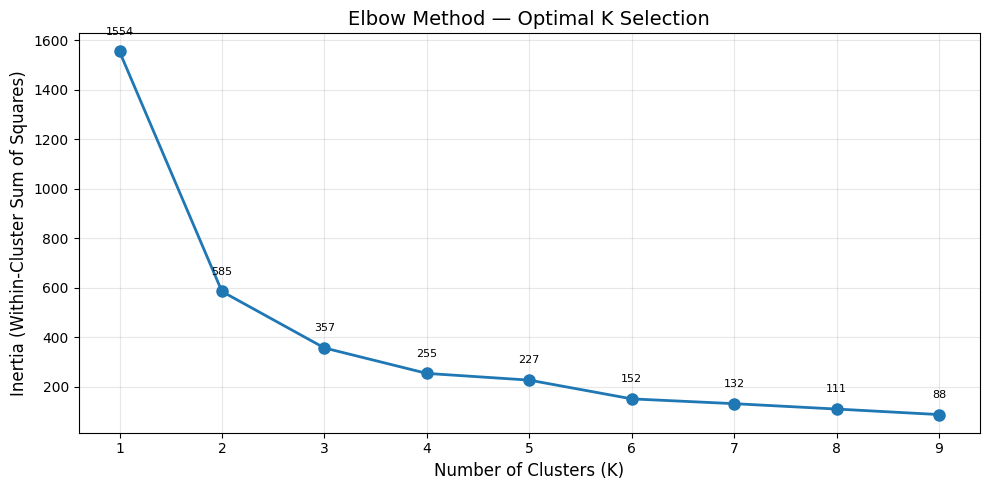

Elbow plot saved to elbow_plot.png


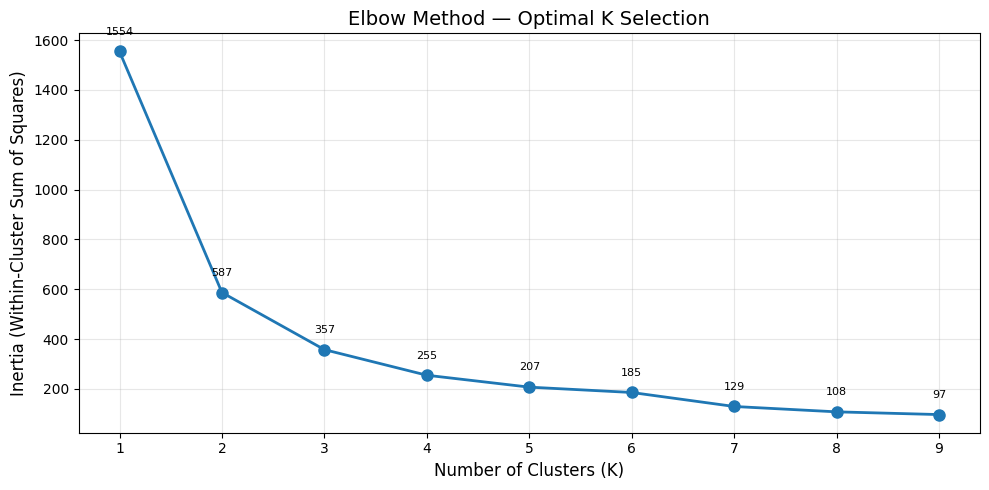

Elbow plot saved to elbow_plot.png


In [15]:
# Run the Elbow Method on the scaled admissions features
# We use scaled applications and scaled enrolment as our
# two clustering features. Using 2 features allows easy 2d visualisation.
optimise_k_means(df[['app_t', 'enr_t']], 10)
optimise_k_means(df[['app_t', 'enr_t']], 10) # so in this plot we can see that the sum of squared distances to the nearest cluster center decreases as we increase the number of clusters. There is a big change in inertia and slope from 2 clusters onwards.

In [17]:
kmeans = KMeans(n_clusters=2) #applying k means clustering
kmeans.fit(df[['app_t', 'enr_t']]) #k means algorithm fit into data
df['kmeans_2'] = kmeans.labels_
# displaying cluster centroids (in scaled space)
print(f"\nCluster centroids (scaled features):")
print(f"  Cluster 0: app_t={kmeans.cluster_centers_[0][0]:.3f}, "
      f"enr_t={kmeans.cluster_centers_[0][1]:.3f}")
print(f"  Cluster 1: app_t={kmeans.cluster_centers_[1][0]:.3f}, "
      f"enr_t={kmeans.cluster_centers_[1][1]:.3f}")


Cluster centroids (scaled features):
  Cluster 0: app_t=2.052, enr_t=2.127
  Cluster 1: app_t=-0.293, enr_t=-0.303


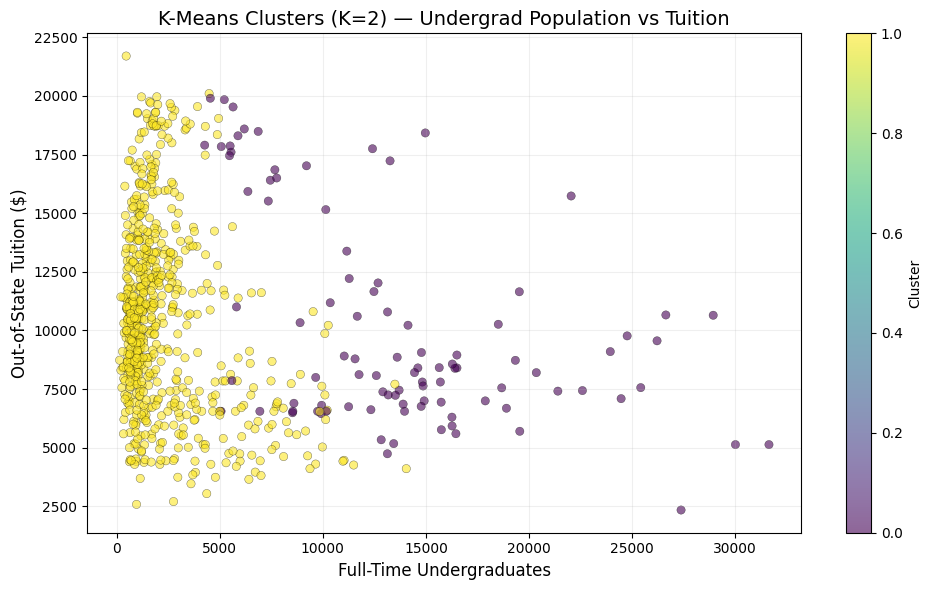

K=2 cluster plot saved to kmeans_k2_scatter.png


In [20]:
# section 5: k=2 clusters visualization
# we want to scatter plot with f.undergrad vs outstate since we want to plot using different features than those used for clustering so it will show to us whether the clusters discovered correspond to meaningful differences in other dimensions. If the clusters separate clearly, it will confirm to us that the clustering captured a real structural pattern in the data not just noise.
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=df['F.Undergrad'],
    y=df['Outstate'],
    c=df['kmeans_2'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='k',
    linewidths=0.3
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Full-Time Undergraduates', fontsize=12)
plt.ylabel('Out-of-State Tuition ($)', fontsize=12)
plt.title('K-Means Clusters (K=2) — Undergrad Population vs Tuition', fontsize=14)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_k2_scatter.png', dpi=150)
plt.show()
print("K=2 cluster plot saved to kmeans_k2_scatter.png")


K=1: Inertia = 1554.00
K=2: Inertia = 586.61
K=3: Inertia = 358.96
K=4: Inertia = 254.62
K=5: Inertia = 210.21


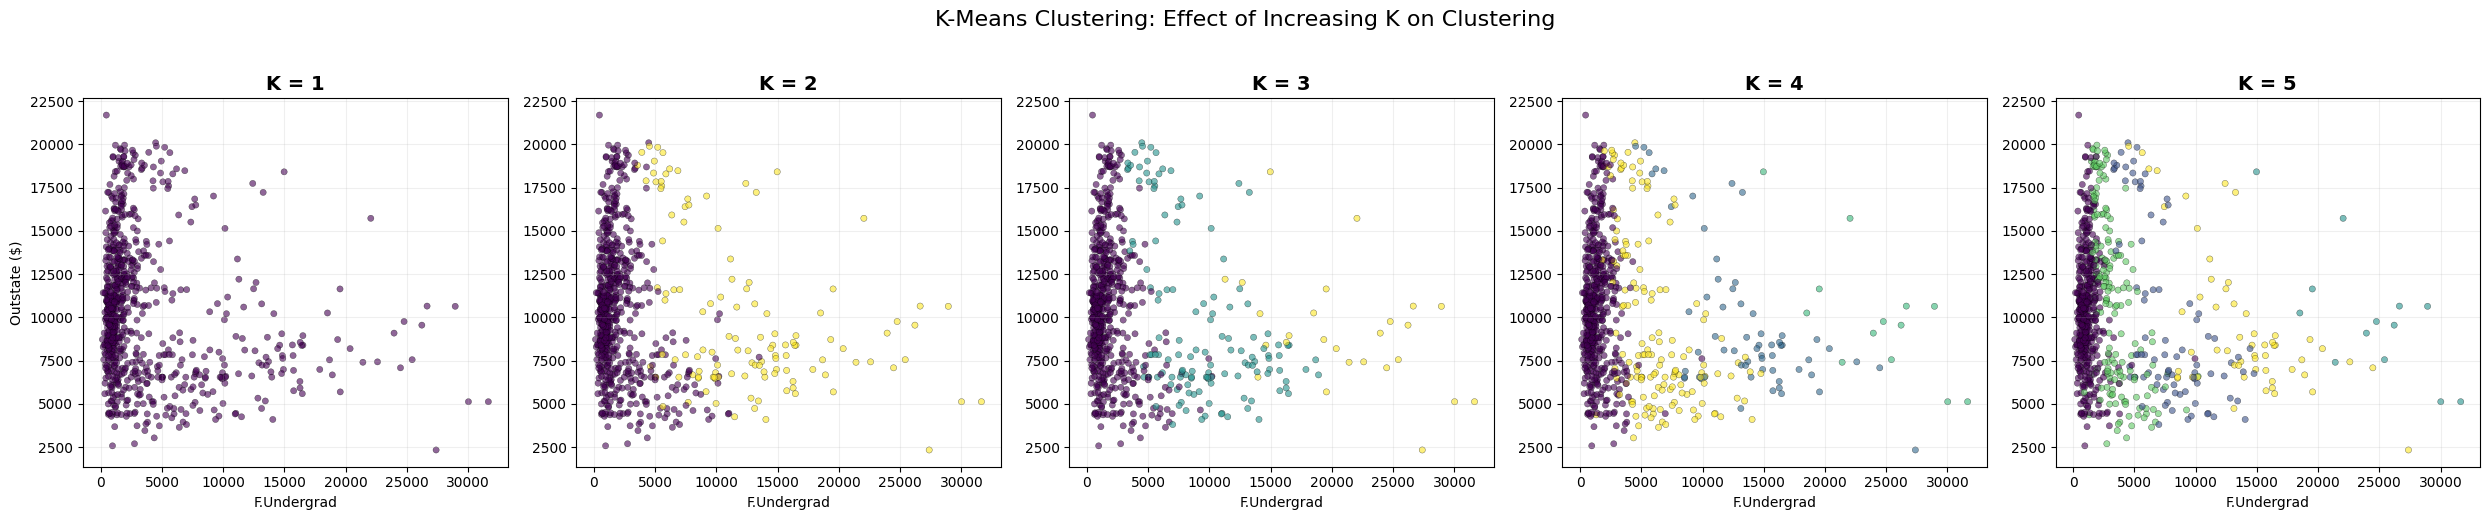

Multi-K comparison saved to kmeans_multi_k_comparison.png. Please see the image if its too small in the output.


In [29]:
# section 6 : compare multiple values of K from 1 to 5
# Elbow method usggested K=2 but its valuable to visually inspect what happends with more clusters. This will help us to validate the elbow choice while doing K=3,4,5 which will reveal either subgroups or just splitting existing clusters arbitrarily. It will also demonstrate the algorithm's behaviour of how Kmeans progressively partitions the data as K increases
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(df[['app_t', 'enr_t']])
    df[f'KMeans_{k}'] = kmeans.labels_
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")


fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(25, 5))

for i, ax in enumerate(axs, start=1):
    scatter = ax.scatter(
        x=df['F.Undergrad'],
        y=df['Outstate'],
        c=df[f'KMeans_{i}'],
        cmap='viridis',
        alpha=0.6,
        edgecolors='k',
        linewidths=0.3,
        s=20
    )
    ax.set_title(f'K = {i}', fontsize=14, fontweight='bold')
    ax.set_xlabel('F.Undergrad')
    ax.set_ylabel('Outstate ($)' if i == 1 else '')
    ax.grid(True, alpha=0.2)

plt.suptitle('K-Means Clustering: Effect of Increasing K on Clustering',
             fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig('kmeans_multi_k_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Multi-K comparison saved to kmeans_multi_k_comparison.png. Please see the image if its too small in the output.")


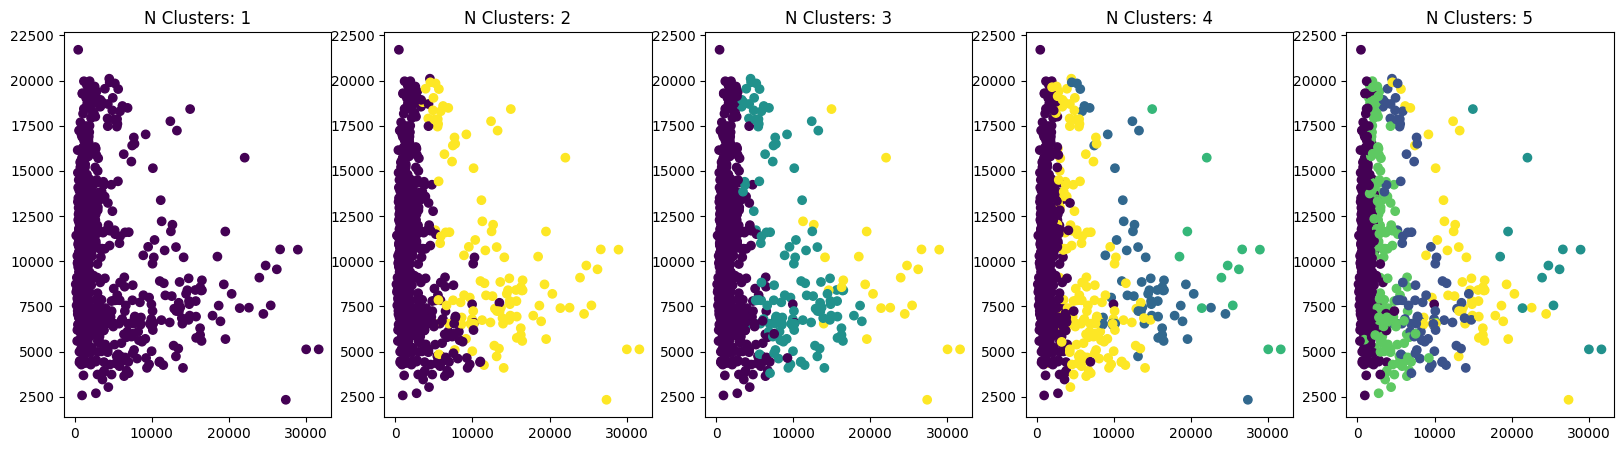

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))

for i, ax in enumerate(fig.axes, start=1):
    ax.scatter(x=df['F.Undergrad'], y=df['Outstate'], c=df[f'KMeans_{i}'])
    ax.set_title(f'N Clusters: {i}')

In [ ]:
# Results Summary:
# The clustering revealed that:

# 1.  K = 2 Elbow Method:
#  The Elbow plot showed the sharpest decrease in inertia from K=1 to K=2
#    with diminishing returns beyond K=2. The data naturally separates into two primary groups.

# 2. Cluster interpretation:
# Cluster 0 as majority:  Universities with lower application and enrolment volumes correlate predominantly to smaller colleges with fewer fulltime undergraduates.
# Cluster 1 as minority:  Universities with higher application and enrolment volumes correlate to larger institutions, often public universities with large student bodies.

# 3. Cross feature validation:
# The scatter plot of F.Undergrad vs Outstate or features NOT used for clustering shows clear separation between clusters. It confirms that the clustering captured a structural pattern not just noise in the two features we clustered on.

# In this project I have demonstrated:
# 1. Working with unsupervised learning since no labels needed
# 2. Using Euclidian Distance based clustering
# 3. Feature scaling as a preprocessing requirement
# 4. Elbow method for model selection
# 5. Cluster visualisation and interpretation
# 6. Discussed the effect of K on cluster granularity
